# NIFTY 50 Forecasting — Step 2: ARIMA / SARIMA Modelling
**Input:** `nifty50_with_indicators.csv` (from Step 1)  
**Goal:** Test stationarity → find best ARIMA order → forecast 30 days → evaluate with RMSE, MAE, MAPE

---

## 0. Install dependencies

In [1]:
import sys
!{sys.executable} -m pip install statsmodels pmdarima --quiet
print('Done!')

Done!



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ARIMA tools
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm   # auto_arima — finds best (p,d,q) automatically

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful!')

All imports successful!


## 2. Load data from Step 1

In [3]:
df = pd.read_csv('nifty50_with_indicators.csv', index_col=0, parse_dates=True)

# We only need Close price for ARIMA
close = df['Close'].copy()

print(f'Loaded {len(close)} rows')
print(f'Date range: {close.index[0].date()} → {close.index[-1].date()}')
print(f'Price range: {close.min():.0f} → {close.max():.0f}')
close.tail(5)

Loaded 1278 rows
Date range: 2019-10-31 → 2024-12-30
Price range: 7610 → 26216


Date
2024-12-23    23753.449219
2024-12-24    23727.650391
2024-12-26    23750.199219
2024-12-27    23813.400391
2024-12-30    23644.900391
Name: Close, dtype: float64

## 3. Stationarity Tests

ARIMA requires a **stationary** series (constant mean and variance over time).  
We test this with two tests:
- **ADF test** — H0: series has a unit root (non-stationary). p < 0.05 → stationary
- **KPSS test** — H0: series is stationary. p < 0.05 → non-stationary

Stock prices are almost always non-stationary — we need to **difference** them.

In [4]:
def test_stationarity(series, name='Series'):
    print(f'\n{'='*50}')
    print(f'  Stationarity Tests: {name}')
    print(f'{'='*50}')
    
    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n  ADF Test:')
    print(f'    Test Statistic : {adf_result[0]:.4f}')
    print(f'    p-value        : {adf_result[1]:.4f}')
    print(f'    Result         : {"STATIONARY" if adf_result[1] < 0.05 else "NON-STATIONARY"} (p < 0.05?)')
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'\n  KPSS Test:')
    print(f'    Test Statistic : {kpss_result[0]:.4f}')
    print(f'    p-value        : {kpss_result[1]:.4f}')
    print(f'    Result         : {"NON-STATIONARY" if kpss_result[1] < 0.05 else "STATIONARY"} (p < 0.05?)')
    
    return adf_result[1], kpss_result[1]

# Test raw Close price
adf_p, kpss_p = test_stationarity(close, 'NIFTY 50 Close Price (Raw)')


  Stationarity Tests: NIFTY 50 Close Price (Raw)

  ADF Test:
    Test Statistic : -0.4497
    p-value        : 0.9015
    Result         : NON-STATIONARY (p < 0.05?)

  KPSS Test:
    Test Statistic : 5.2596
    p-value        : 0.0100
    Result         : NON-STATIONARY (p < 0.05?)


C:\Users\pavan\AppData\Local\Temp\ipykernel_15000\2750772533.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


In [5]:
# First difference — removes trend
close_diff1 = close.diff().dropna()
adf_p1, kpss_p1 = test_stationarity(close_diff1, 'NIFTY 50 — First Difference')


  Stationarity Tests: NIFTY 50 — First Difference

  ADF Test:
    Test Statistic : -37.0649
    p-value        : 0.0000
    Result         : STATIONARY (p < 0.05?)

  KPSS Test:
    Test Statistic : 0.0662
    p-value        : 0.1000
    Result         : STATIONARY (p < 0.05?)


C:\Users\pavan\AppData\Local\Temp\ipykernel_15000\2750772533.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


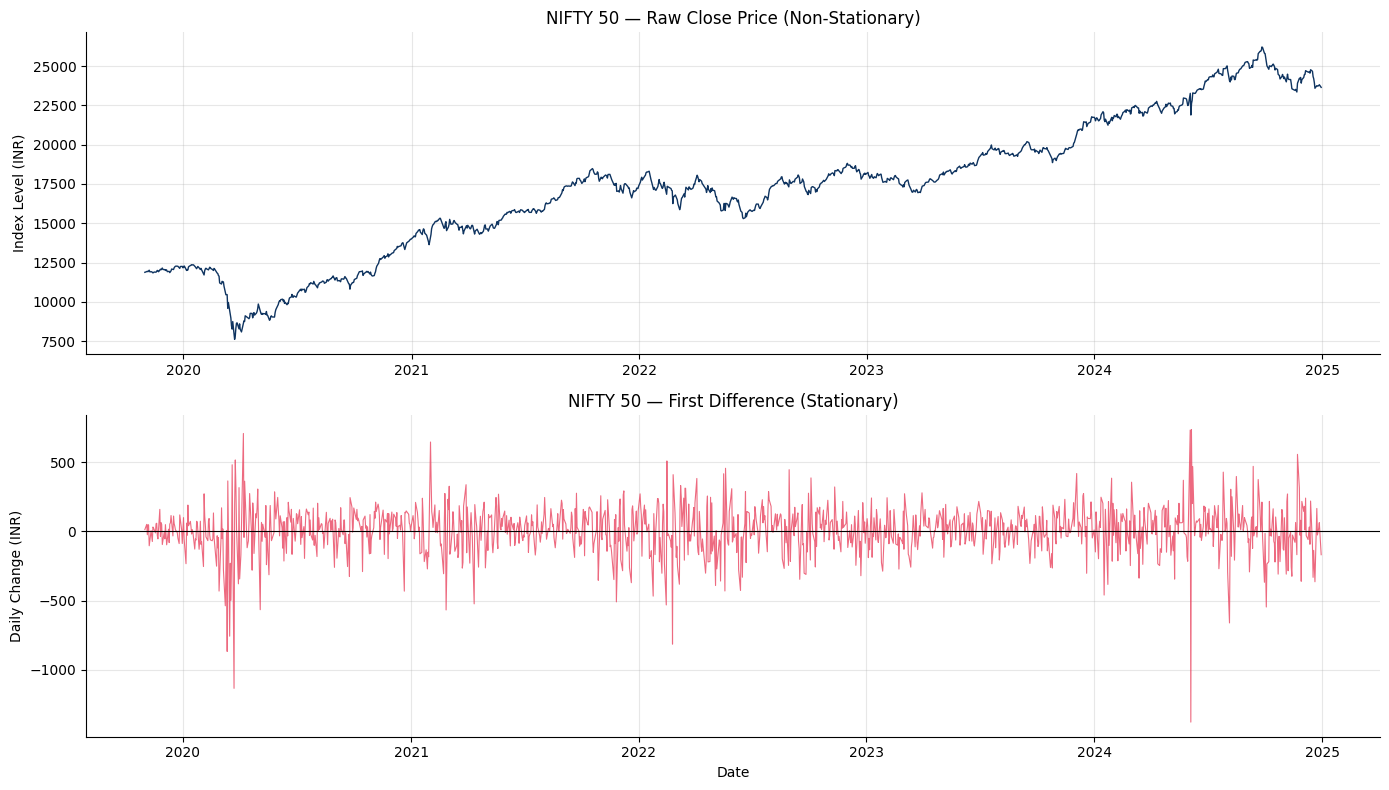

Conclusion: d=1 (one differencing step makes the series stationary)


In [6]:
# Visualise raw vs differenced
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(close.index, close, color='#0f3460', linewidth=1)
axes[0].set_title('NIFTY 50 — Raw Close Price (Non-Stationary)', fontsize=12)
axes[0].set_ylabel('Index Level (INR)')

axes[1].plot(close_diff1.index, close_diff1, color='#e94560', linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('NIFTY 50 — First Difference (Stationary)', fontsize=12)
axes[1].set_ylabel('Daily Change (INR)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('nifty_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Conclusion: d=1 (one differencing step makes the series stationary)')

## 4. ACF & PACF Plots
These tell us what values of **p** (AR order) and **q** (MA order) to use in ARIMA(p, d, q).
- **ACF** → suggests q (MA order) — cut off after lag q
- **PACF** → suggests p (AR order) — cut off after lag p

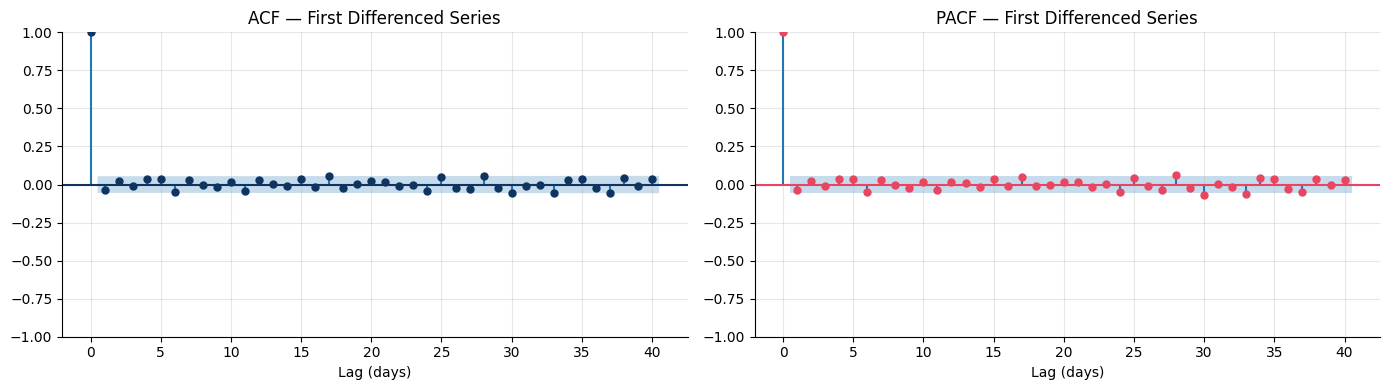

Reading the plots:
  ACF  cuts off quickly → small q (MA order)
  PACF cuts off quickly → small p (AR order)
  We will let auto_arima find the exact values


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(close_diff1, lags=40, ax=axes[0], color='#0f3460', alpha=0.05)
axes[0].set_title('ACF — First Differenced Series', fontsize=12)
axes[0].set_xlabel('Lag (days)')

plot_pacf(close_diff1, lags=40, ax=axes[1], color='#e94560', alpha=0.05, method='ywm')
axes[1].set_title('PACF — First Differenced Series', fontsize=12)
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.savefig('nifty_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reading the plots:')
print('  ACF  cuts off quickly → small q (MA order)')
print('  PACF cuts off quickly → small p (AR order)')
print('  We will let auto_arima find the exact values')

## 5. Seasonal Decomposition
Separate trend, seasonality, and residual components.

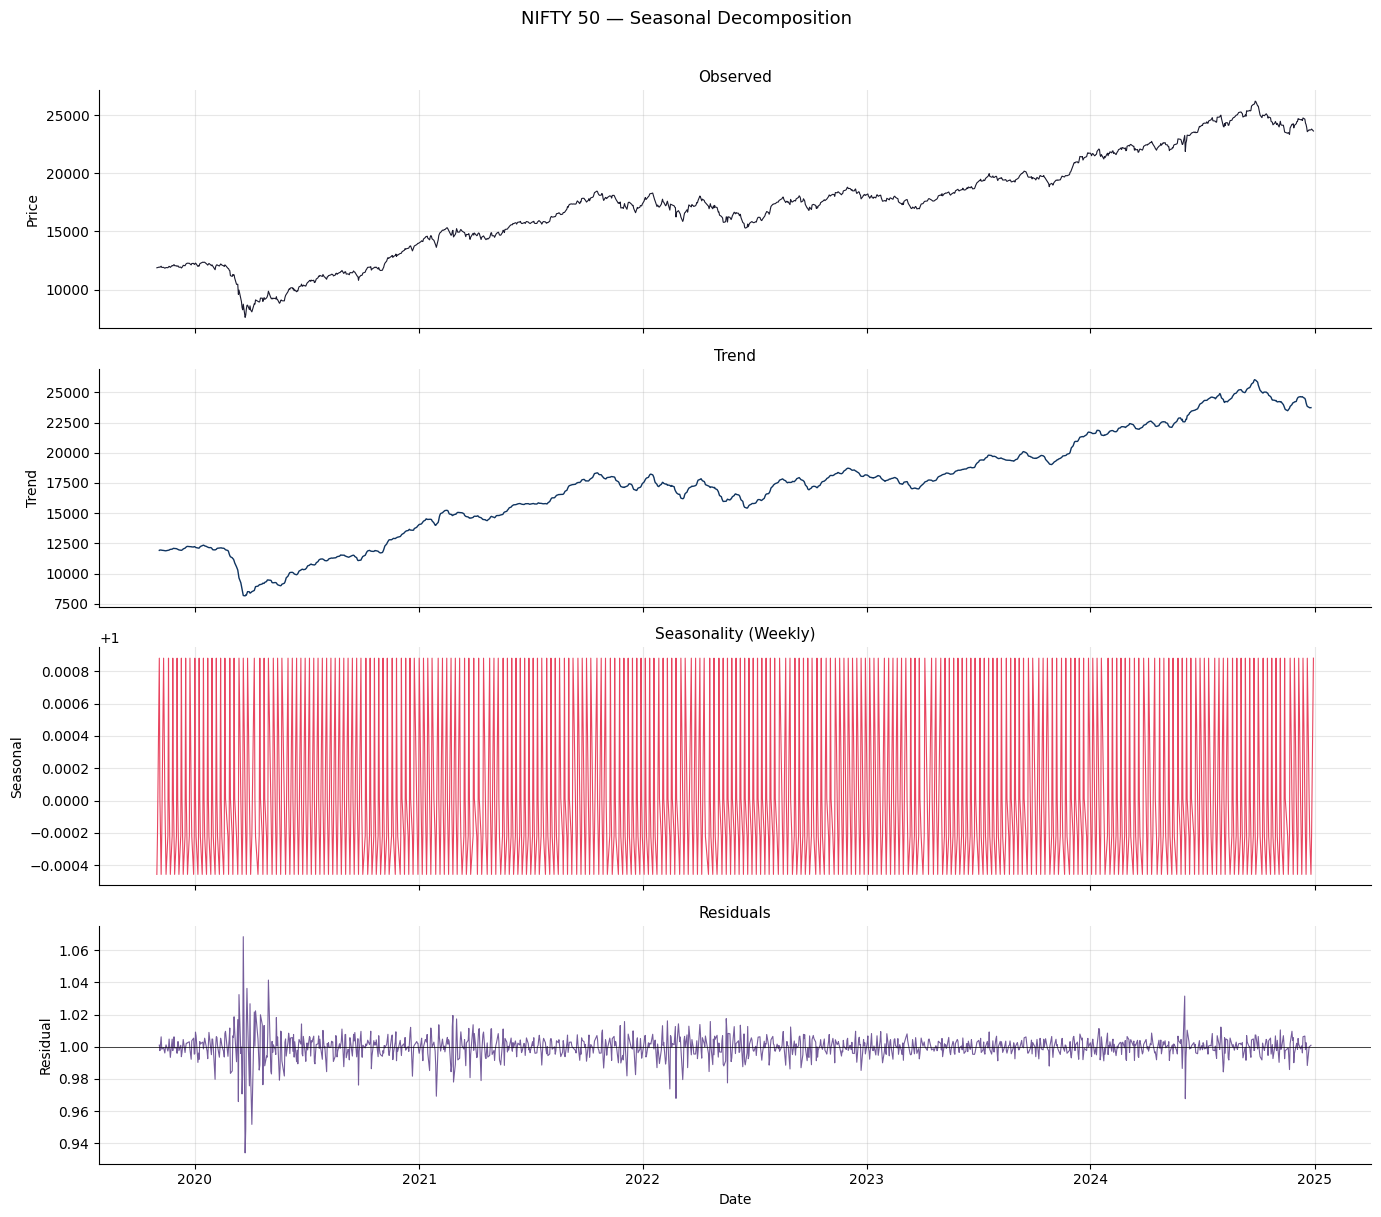

In [8]:
# Use weekly seasonality (5 trading days)
decomp = seasonal_decompose(close, model='multiplicative', period=5)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(decomp.observed, color='#1a1a2e', linewidth=0.8)
axes[0].set_title('Observed', fontsize=11)
axes[0].set_ylabel('Price')

axes[1].plot(decomp.trend, color='#0f3460', linewidth=1)
axes[1].set_title('Trend', fontsize=11)
axes[1].set_ylabel('Trend')

axes[2].plot(decomp.seasonal, color='#e94560', linewidth=0.8)
axes[2].set_title('Seasonality (Weekly)', fontsize=11)
axes[2].set_ylabel('Seasonal')

axes[3].plot(decomp.resid, color='#533483', linewidth=0.8, alpha=0.8)
axes[3].axhline(1, color='black', linewidth=0.5)
axes[3].set_title('Residuals', fontsize=11)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.suptitle('NIFTY 50 — Seasonal Decomposition', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('nifty_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Train / Test Split
Use last 60 trading days (~3 months) as test set.

Train: 1218 days  (2019-10-31 → 2024-10-01)
Test : 60  days  (2024-10-03  → 2024-12-30)


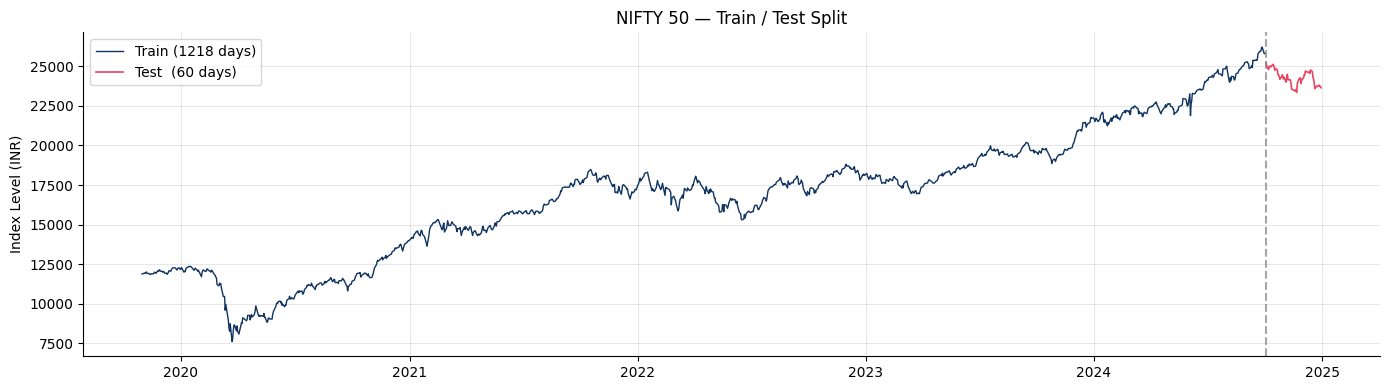

In [9]:
TEST_SIZE = 60   # last 60 trading days = ~3 months

train = close[:-TEST_SIZE]
test  = close[-TEST_SIZE:]

print(f'Train: {len(train)} days  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)}  days  ({test.index[0].date()}  → {test.index[-1].date()})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train, color='#0f3460', linewidth=1,   label=f'Train ({len(train)} days)')
ax.plot(test.index,  test,  color='#e94560', linewidth=1.2, label=f'Test  ({len(test)} days)')
ax.axvline(test.index[0], color='gray', linestyle='--', alpha=0.7)
ax.set_title('NIFTY 50 — Train / Test Split', fontsize=12)
ax.set_ylabel('Index Level (INR)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Auto ARIMA — Find Best (p, d, q)
`auto_arima` tries many combinations and picks the one with lowest AIC score.  
This takes 1–2 minutes — normal!

In [10]:
print('Running auto_arima... (takes 1-2 minutes)')

auto_model = pm.auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,              # we know d=1 from stationarity test
    seasonal=False,   # no strong seasonality in NIFTY daily data
    stepwise=True,    # faster search
    information_criterion='aic',
    trace=True,       # prints each model being tested
    error_action='ignore',
    suppress_warnings=True
)

print(f'\nBest model: ARIMA{auto_model.order}')
print(f'AIC: {auto_model.aic():.2f}')

Running auto_arima... (takes 1-2 minutes)
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15947.363, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=15946.544, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=15946.647, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=15950.909, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=15948.270, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=15947.913, Time=0.40 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=15950.192, Time=0.33 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=15950.632, Time=0.02 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 1.006 seconds

Best model: ARIMA(1, 1, 0)
AIC: 15946.54


In [11]:
# Model summary
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1218
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -7970.272
Date:                Sun, 29 Mar 2026   AIC                          15946.544
Time:                        12:25:17   BIC                          15961.857
Sample:                             0   HQIC                         15952.308
                               - 1218                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     11.9885      5.183      2.313      0.021       1.829      22.148
ar.L1         -0.0480      0.018     -2.623      0.009      -0.084      -0.012
sigma2       2.86e+04    676.300     42.289      0.0

## 8. Forecast on Test Set

In [12]:
# Forecast next 60 days (our test period)
forecast, conf_int = auto_model.predict(n_periods=TEST_SIZE, return_conf_int=True)

forecast_series = pd.Series(forecast, index=test.index)
ci_lower = pd.Series(conf_int[:, 0], index=test.index)
ci_upper = pd.Series(conf_int[:, 1], index=test.index)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test.values - forecast) / test.values)) * 100

print(f'ARIMA{auto_model.order} — Test Set Performance')
print(f'  RMSE : {rmse:,.2f} points')
print(f'  MAE  : {mae:,.2f} points')
print(f'  MAPE : {mape:.2f}%')

# Save metrics for Step 5 comparison
arima_metrics = {'Model': f'ARIMA{auto_model.order}', 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
print(f'\nMetrics saved for final comparison.')

ARIMA(1, 1, 0) — Test Set Performance
  RMSE : 1,912.23 points
  MAE  : 1,813.08 points
  MAPE : 7.50%

Metrics saved for final comparison.


f:\.venv-1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


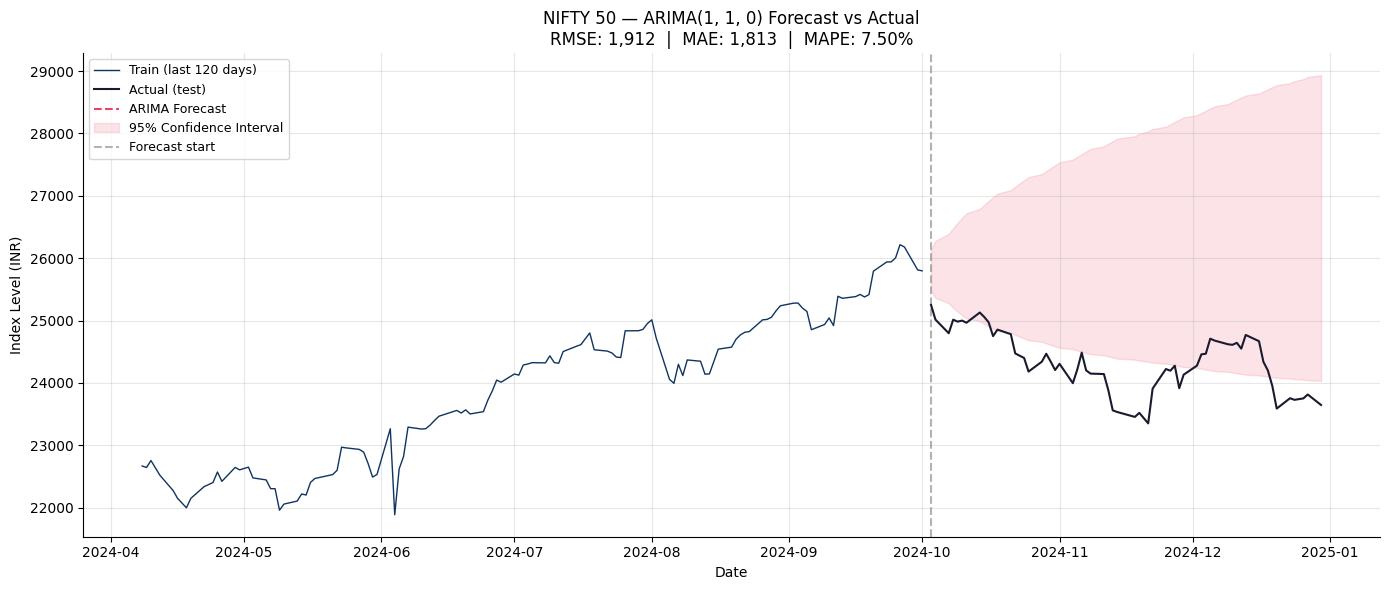

In [13]:
# Plot forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))

# Show last 120 days of train for context
ax.plot(train.index[-120:], train.iloc[-120:],
        color='#0f3460', linewidth=1, label='Train (last 120 days)')
ax.plot(test.index,  test,
        color='#1a1a2e', linewidth=1.5, label='Actual (test)', zorder=5)
ax.plot(forecast_series.index, forecast_series,
        color='#e94560', linewidth=1.5, linestyle='--', label=f'ARIMA Forecast')
ax.fill_between(forecast_series.index, ci_lower, ci_upper,
                alpha=0.15, color='#e94560', label='95% Confidence Interval')
ax.axvline(test.index[0], color='gray', linestyle='--', alpha=0.6, label='Forecast start')

ax.set_title(f'NIFTY 50 — ARIMA{auto_model.order} Forecast vs Actual\nRMSE: {rmse:,.0f}  |  MAE: {mae:,.0f}  |  MAPE: {mape:.2f}%',
             fontsize=12)
ax.set_ylabel('Index Level (INR)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('nifty_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Residual Diagnostics
Good ARIMA residuals should look like white noise — no patterns left.

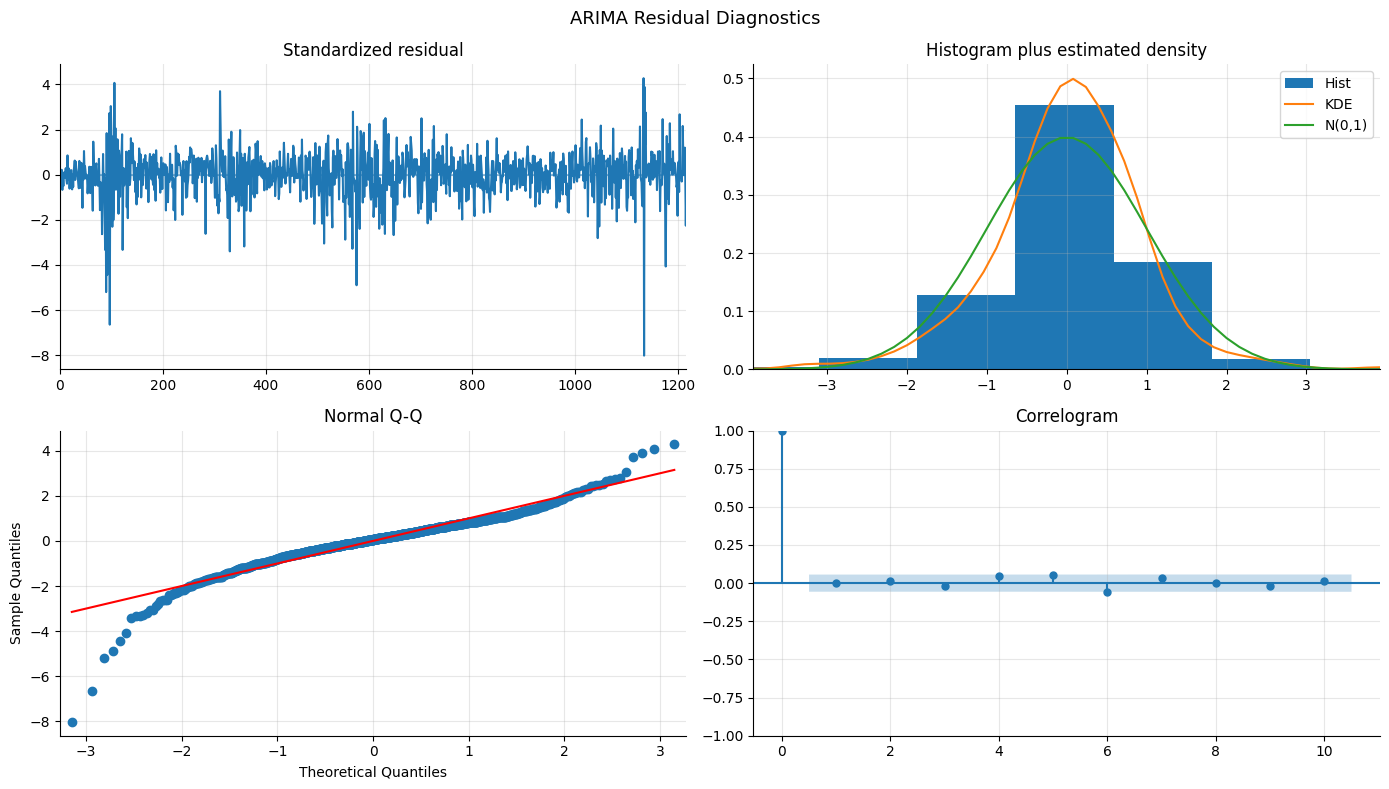

What to look for:
  Standardised residuals → no pattern, centred around 0
  Histogram + KDE        → roughly normal distribution
  Q-Q plot               → points close to the diagonal line
  Correlogram            → no significant spikes after lag 0


In [14]:
auto_model.plot_diagnostics(figsize=(14, 8))
plt.suptitle('ARIMA Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('nifty_arima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print('What to look for:')
print('  Standardised residuals → no pattern, centred around 0')
print('  Histogram + KDE        → roughly normal distribution')
print('  Q-Q plot               → points close to the diagonal line')
print('  Correlogram            → no significant spikes after lag 0')

## 10. Walk-Forward Validation
More realistic evaluation — forecast 1 day at a time, refit each day.  
This is how you would actually use ARIMA in production.

In [15]:
print('Running walk-forward validation... (takes ~1 minute)')

history     = list(train)
predictions = []
p, d, q     = auto_model.order

for i in range(len(test)):
    model = ARIMA(history, order=(p, d, q))
    fit   = model.fit()
    yhat  = fit.forecast(steps=1)[0]
    predictions.append(yhat)
    history.append(test.iloc[i])   # add real value for next iteration
    
    if i % 10 == 0:
        print(f'  Day {i+1}/{len(test)} done...')

predictions = np.array(predictions)

wf_rmse = np.sqrt(mean_squared_error(test, predictions))
wf_mae  = mean_absolute_error(test, predictions)
wf_mape = np.mean(np.abs((test.values - predictions) / test.values)) * 100

print(f'\nWalk-Forward ARIMA{auto_model.order} Performance:')
print(f'  RMSE : {wf_rmse:,.2f} points')
print(f'  MAE  : {wf_mae:,.2f} points')
print(f'  MAPE : {wf_mape:.2f}%')

Running walk-forward validation... (takes ~1 minute)
  Day 1/60 done...
  Day 11/60 done...
  Day 21/60 done...
  Day 31/60 done...
  Day 41/60 done...
  Day 51/60 done...

Walk-Forward ARIMA(1, 1, 0) Performance:
  RMSE : 203.50 points
  MAE  : 159.30 points
  MAPE : 0.66%


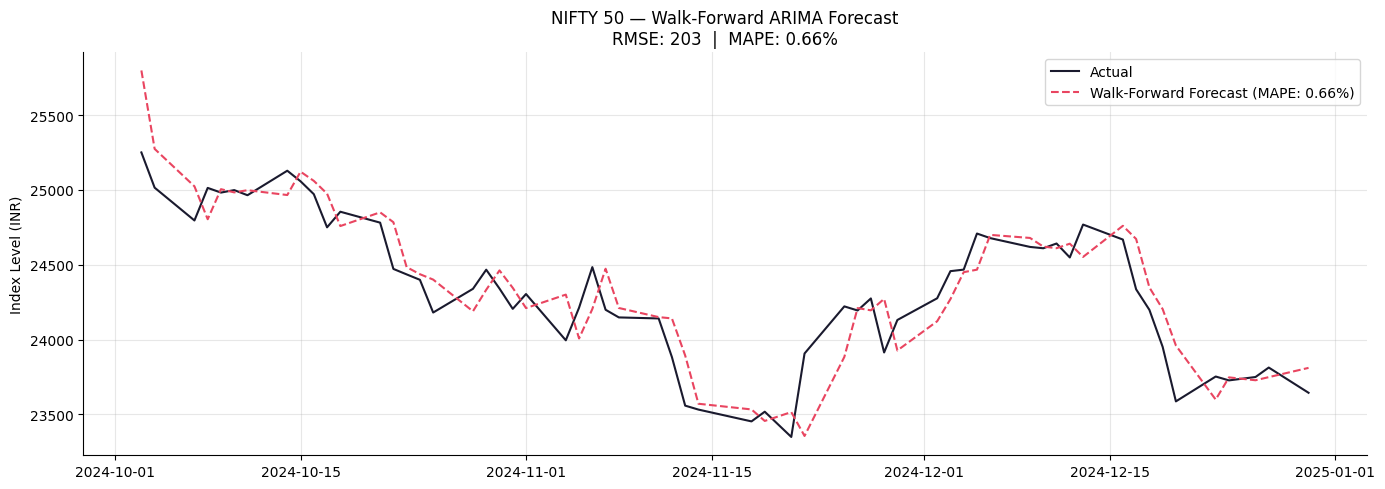

In [16]:
# Plot walk-forward forecast
pred_series = pd.Series(predictions, index=test.index)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test.values,       color='#1a1a2e', linewidth=1.5, label='Actual')
ax.plot(test.index, pred_series.values,color='#e94560', linewidth=1.5,
        linestyle='--', label=f'Walk-Forward Forecast (MAPE: {wf_mape:.2f}%)')
ax.set_title(f'NIFTY 50 — Walk-Forward ARIMA Forecast\nRMSE: {wf_rmse:,.0f}  |  MAPE: {wf_mape:.2f}%', fontsize=12)
ax.set_ylabel('Index Level (INR)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('nifty_walkforward_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save results for Step 5 comparison

In [17]:
# Save walk-forward predictions to CSV
results_df = pd.DataFrame({
    'Date'       : test.index,
    'Actual'     : test.values,
    'ARIMA_Pred' : predictions
}).set_index('Date')

results_df.to_csv('arima_predictions.csv')

print('Saved: arima_predictions.csv')
print(f'\nARIMA Summary:')
print(f'  Best order : ARIMA{auto_model.order}')
print(f'  RMSE       : {wf_rmse:,.2f}')
print(f'  MAE        : {wf_mae:,.2f}')
print(f'  MAPE       : {wf_mape:.2f}%')
print(f'\nStep 2 complete! Ready for Step 3 — Facebook Prophet')

Saved: arima_predictions.csv

ARIMA Summary:
  Best order : ARIMA(1, 1, 0)
  RMSE       : 203.50
  MAE        : 159.30
  MAPE       : 0.66%

Step 2 complete! Ready for Step 3 — Facebook Prophet


---
## Project progress

| Step | Notebook | Status |
|------|----------|--------|
| Step 1 | Data + Indicators | ✅ Done |
| Step 2 | ARIMA / SARIMA | ✅ Done |
| Step 3 | Facebook Prophet | ⬅ Next |
| Step 4 | LSTM | Pending |
| Step 5 | Model comparison + Backtest | Pending |